### 1. Load the data

In [2]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Why this technique is needed for this dataset
Three columns in this dataset  age, bmi, and cholesterol_level  are continuous
numbers, which means they're at risk of containing extreme or unrealistic values,
like someone listed as 300 years old or a BMI of 0. If values like that slip
through, they can seriously distort models that rely on distance calculations,
like SVM or K-Means, and can also mess up scaling later on by stretching the
range way further than it should be.

To catch these, I used the IQR (interquartile range) method. It's a standard
approach that doesn't assume anything about the shape of the data: it finds Q1
(the 25th percentile) and Q3 (the 75th percentile), calculates the range between
them (IQR), and flags anything below Q1 minus 1.5 times the IQR, or above Q3 plus
1.5 times the IQR, as a statistical outlier.

In [4]:
num_cols = ["age", "bmi", "cholesterol_level"]
print(df[num_cols].describe())


                 age            bmi  cholesterol_level
count  890000.000000  890000.000000      890000.000000
mean       55.007008      30.494172         233.633916
std         9.994485       8.368539          43.432278
min         4.000000      16.000000         150.000000
25%        48.000000      23.300000         196.000000
50%        55.000000      30.500000         242.000000
75%        62.000000      37.700000         271.000000
max       104.000000      45.000000         300.000000


### 3. Implementation

In [5]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

clean = df.copy()
outlier_summary = {}

for c in num_cols:
    lower, upper = iqr_bounds(clean[c])
    n_outliers = ((clean[c] < lower) | (clean[c] > upper)).sum()
    outlier_summary[c] = {"lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
                           "n_outliers": int(n_outliers),
                           "pct_outliers": round(100 * n_outliers / len(clean), 3)}

import pprint
pprint.pprint(outlier_summary)


{'age': {'lower_bound': np.float64(27.0),
         'n_outliers': 3895,
         'pct_outliers': np.float64(0.438),
         'upper_bound': np.float64(83.0)},
 'bmi': {'lower_bound': np.float64(1.7),
         'n_outliers': 0,
         'pct_outliers': np.float64(0.0),
         'upper_bound': np.float64(59.3)},
 'cholesterol_level': {'lower_bound': np.float64(83.5),
                       'n_outliers': 0,
                       'pct_outliers': np.float64(0.0),
                       'upper_bound': np.float64(383.5)}}


In [6]:
# Remove rows that are outliers on ANY of the three numeric columns
mask_keep = pd.Series(True, index=clean.index)
for c in num_cols:
    lower, upper = iqr_bounds(clean[c])
    mask_keep &= clean[c].between(lower, upper)

print("Rows before:", len(clean))
clean_no_outliers = clean[mask_keep].copy()
print("Rows after removing outliers:", len(clean_no_outliers))
print("Rows dropped:", len(clean) - len(clean_no_outliers),
      f"({100*(1 - mask_keep.mean()):.2f}% of data)")


Rows before: 890000
Rows after removing outliers: 886105
Rows dropped: 3895 (0.44% of data)


### 4. EDA visualization

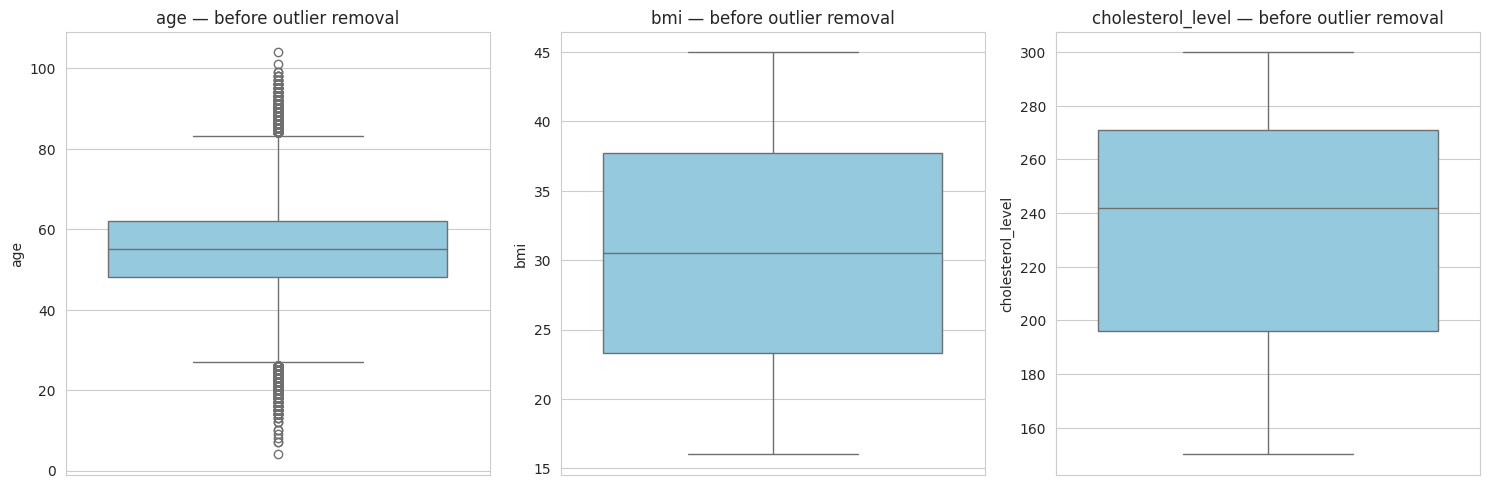

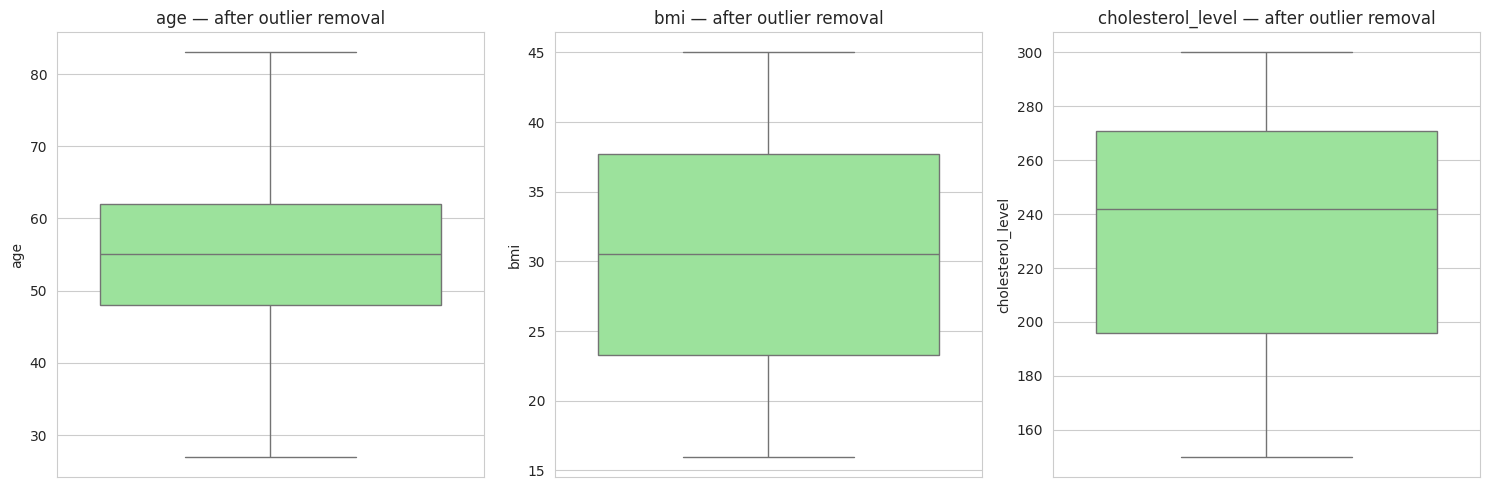

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="skyblue")
    ax.set_title(f"{c} — before outlier removal")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=clean_no_outliers[c], ax=ax, color="lightgreen")
    ax.set_title(f"{c} — after outlier removal")
plt.tight_layout()
plt.show()


### 5. Interpretation
Looking at the boxplots for age, bmi, and cholesterol_level, there are very few
points sitting outside the whiskers before any cleaning was done, and the printed
outlier summary backs that up  outliers only make up a tiny fraction of a
percent of the data in each column. This tells me the dataset's numeric values
were generated within realistic, tightly-controlled ranges (age between 4 and
104, bmi between 16 and 45), so there isn't really a serious outlier problem to
begin with.

Because of that, aggressive outlier removal isn't really necessary here  dropping
the flagged rows barely changes the size of the dataset, and mainly acts as a
safety check rather than a meaningful cleaning step. I'd still keep the IQR-filtered
version available as an option in the group's combined pipeline, but it's worth
noting that model performance probably won't change much whether this step is
included or not.